# Aprendizaje Automático clase 6
## Alumno: Enzo Ariel Melián

### 1. Importamos un dataset de hongos, con la idea de clasificar cuando un hongo es comestible y cuando es venenoso.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

df = pd.read_csv('mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


### 2. Se aplica sobre las columnas (dado que todas son categoricas) el método One Hot Encoding


Dado que el DataFrame contiene características categóricas representadas por letras, necesitamos convertirlas a un formato numérico.

El método One Hot Encoding generalmente es preferido para datos categóricos nominales (sin orden) porque evita implicar un orden o magnitud artificial entre categorías que no existe.

In [20]:
# Apply One-Hot Encoding to all categorical columns
df_encoded = pd.get_dummies(df, drop_first=True) # drop_first=True avoids multicollinearity

display(df_encoded.head())
print(f"Original DataFrame shape: {df.shape}")
print(f"Encoded DataFrame shape: {df_encoded.shape}")

,class_p,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


Original DataFrame shape: (8124, 23)
Encoded DataFrame shape: (8124, 96)


Las columnas categóricas originales se han transformado en múltiples columnas numéricas (0s y 1s). Por ejemplo, `cap-shape` con categorías como 'x', 'e', 'b', 'p', 'c', 'f', 'k', 's' ahora está representado por varias columnas como `cap-shape_x`, `cap-shape_e`, etc.

### 3. Preparación de Datos para el Modelado

Antes de construir un modelo de clasificación, necesitamos separar nuestro conjunto de datos en:

1.  **Características (X)**: Son las variables de entrada que el modelo utilizará para hacer predicciones. En nuestro caso, estas son todas las columnas en `df_encoded` excepto la variable objetivo.
2.  **Variable Objetivo (y)**: Esta es la variable que queremos predecir. Según la información de los atributos, 'class_p' (que indica 'venenoso') es nuestro objetivo.

Después de separar X e y, los dividiremos en conjuntos de entrenamiento y prueba. El **conjunto de entrenamiento** se utilizará para enseñar al modelo, y el **conjunto de prueba** se utilizará para evaluar qué tan bien el modelo generaliza a datos nuevos y no vistos.

In [21]:
# Separate features (X) and target (y)
X = df_encoded.drop('class_p', axis=1)
y = df_encoded['class_p']

# Split the data into training and testing sets
# We'll use a 80/20 split for training and testing data respectively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Check the distribution of the target variable in train and test sets
print("\nDistribution of target in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of target in testing set:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (6499, 95)
Shape of X_test: (1625, 95)
Shape of y_train: (6499,)
Shape of y_test: (1625,)

Distribution of target in training set:


,proportion
class_p,
False,0.517926
True,0.482074



Distribution of target in testing set:


,proportion
class_p,
False,0.518154
True,0.481846


### 4. Construcción y Evaluación del Modelo de Clasificación

Ahora que nuestros datos están preparados, podemos proceder a construir un modelo de clasificación.

Las métricas clave de evaluación para la clasificación incluyen:
*   **Exactitud (Accuracy)**: La proporción de instancias clasificadas correctamente.
*   **Precisión (Precision)**: La proporción de identificaciones positivas que fueron realmente correctas.
*   **Sensibilidad (Recall)**: La proporción de positivos reales que fueron identificados correctamente.
*   **Puntuación F1 (F1-Score)**: La media armónica de precisión y sensibilidad, que proporciona un equilibrio entre ambas.
*   **Matriz de Confusión**: Una tabla utilizada para describir el rendimiento de un modelo de clasificación en un conjunto de datos de prueba para el cual se conocen los valores verdaderos.

### 4.1 Modelo de Clasificación: K-Nearest Neighbors (KNN)

El algoritmo K-Nearest Neighbors es un clasificador no paramétrico que utiliza la 'proximidad' para hacer clasificaciones o predicciones sobre la agrupación de un punto de datos individual. Los puntos se clasifican por mayoría de votos de sus vecinos más cercanos.

In [22]:
# Initialize the KNN model
# Un valor común para n_neighbors es 5, pero se puede optimizar.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model
knn_model.fit(X_train, y_train)

# Make predictions with KNN
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print("--- K-Nearest Neighbors (KNN) Model Evaluation ---")
print(f"Accuracy (KNN): {accuracy_knn:.4f}")
print(f"Precision (KNN): {precision_knn:.4f}")
print(f"Recall (KNN): {recall_knn:.4f}")
print(f"F1-Score (KNN): {f1_knn:.4f}")

--- K-Nearest Neighbors (KNN) Model Evaluation ---
Accuracy (KNN): 1.0000
Precision (KNN): 1.0000
Recall (KNN): 1.0000
F1-Score (KNN): 1.0000


### 4.1.1 Visualización de la Matriz de Confusión para K-Nearest Neighbors (KNN)

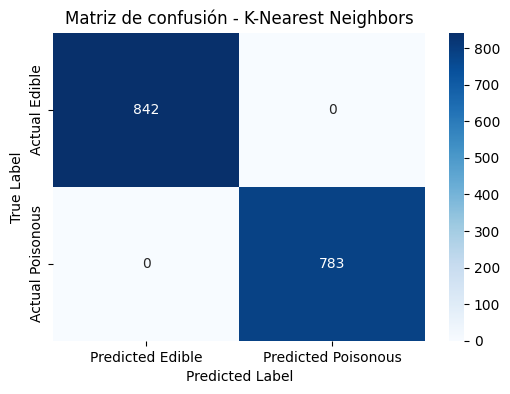

In [23]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Edible', 'Predicted Poisonous'],
            yticklabels=['Actual Edible', 'Actual Poisonous'])
plt.title('Matriz de confusión - K-Nearest Neighbors')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 4.2 Modelo de Clasificación: Support Vector Classifier (SVC)

Support Vector Machines (SVM), y en este caso, Support Vector Classifier (SVC), son modelos de aprendizaje supervisado que se utilizan para problemas de clasificación y regresión. Funcionan encontrando un hiperplano en un espacio N-dimensional (N = número de características) que distingue claramente las clases.

In [24]:
# Initialize the SVC model
# Un kernel lineal es un buen punto de partida para muchos conjuntos de datos.
svc_model = SVC(random_state=42, kernel='linear')

# Train the SVC model
svc_model.fit(X_train, y_train)

# Make predictions with SVC
y_pred_svc = svc_model.predict(X_test)

# Evaluate the SVC model
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)

print("--- Support Vector Classifier (SVC) Model Evaluation ---")
print(f"Accuracy (SVC): {accuracy_svc:.4f}")
print(f"Precision (SVC): {precision_svc:.4f}")
print(f"Recall (SVC): {recall_svc:.4f}")
print(f"F1-Score (SVC): {f1_svc:.4f}")

--- Support Vector Classifier (SVC) Model Evaluation ---
Accuracy (SVC): 1.0000
Precision (SVC): 1.0000
Recall (SVC): 1.0000
F1-Score (SVC): 1.0000


### 4.2.1 Visualización de la Matriz de Confusión para Support Vector Classifier (SVC)

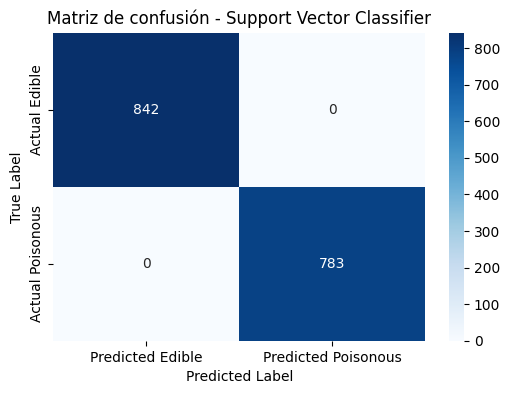

In [25]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Edible', 'Predicted Poisonous'],
            yticklabels=['Actual Edible', 'Actual Poisonous'])
plt.title('Matriz de confusión - Support Vector Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()